# Routing

While a sequential workflow, as seen in the Prompt Chaining pattern, is foundational to think about multi-step agent applications, it has several limitations:
- It lacks the ability to make decisions based on context. 
- Without a mechanism to choose the correct tool or sub-process for a specific task, the system remains rigid and non-adaptative. 
- It makes difficult to build sophisticated applications that can manage the complexity and variability of real-world user requests.

The Routing pattern provides a solution by introducing conditional logic, enabling the system to first analyze an incoming query to determine its intent or nature. Based on this analysis, the agent dynamically directs the flow of control to the most appropriate specialized tool, function, or sub-agent.



> **🧭 When to use this pattern — and how Flyte helps**
>
> Use routing when the agent must choose among several workflows, tools, or sub-agents based on the input — triaging or classifying requests (e.g. sales vs. support vs. billing). With Flyte's `Agent`, each route is a tool that runs as its own traced sub-action, and every handler can carry its own resources, image, and retries.

## Implementation with Flyte v2 + the Agent harness

This notebook refactors the original LangChain + LangGraph routing example into a Flyte v2 `Agent`. Instead of a hand-written LLM classifier feeding a Python `if/else`, **the routing _is_ the agent**: each route is a tool, and the harness classifies the request and dispatches to exactly one tool in a single managed step.

#### LangGraph vs Flyte v2 + Agent harness

| Aspect | LangGraph | Flyte v2 + `Agent` harness |
|--------|-----------|----------------------------|
| **Routing logic** | Explicit graph with nodes/edges | `Agent` selects a tool — one tool == one route |
| **Classifier** | A node you write and prompt | Built into the harness' tool-choice step |
| **State** | Shared typed dict flowing through nodes | Typed `AgentResult` |
| **Human-in-the-loop** | Built-in graph interrupts | `@tool(requires_approval=True)` (HITL plugin) |
| **Observability** | LangSmith | Each route handler is a nested, traced `@env.task` |
| **Execution model** | In-process only | Separate pods per task |
| **Per-task resources/images** | No | Yes |
| **Secrets** | `.env` / `os.environ` | `flyte.Secret` injected by cluster |

1. Install dependencies

In [ ]:
!uv pip install flyte litellm

### Start the devbox

If you haven't already, install the flyte package with the command above, then launch the local cluster:

In [ ]:
!flyte start devbox

2. Create a secret in Flyte for the API key (only done once):

In [ ]:
!flyte create secret ANTHROPIC_API_KEY --value sk-...

3. Import dependencies and declare the resources your execution environment will need, using the `TaskEnvironment` class. This allows you to allocate precise resources and run agents on their own container with all dependencies baked in automatically:

In [6]:
import os
import asyncio
import flyte
from flyte import TaskEnvironment, Resources, Secret
from flyte.ai.agents import Agent, AgentResult

flyte.init_from_config()

env = TaskEnvironment(
    name="routing_env",
    resources=Resources(cpu="1", memory="1Gi"),
    cache="auto",
    image=flyte.Image.from_debian_base().with_pip_packages("litellm"),
    secrets=[flyte.Secret(key="ANTHROPIC_API_KEY", as_env_var="ANTHROPIC_API_KEY")],
)

## Routing as tool dispatch

In the Agent harness, **routing is tool selection**. Each route becomes an `@env.task` tool with a docstring describing when to use it. The agent reads the request, picks exactly one tool, and runs it — replacing both the hand-written classifier (`router_node`) and the `if/else` dispatcher from the plain-task version.

First, define the three route handlers as tools:

Each route handler is a normal `@env.task`. Its **docstring** tells the agent when to choose it; the request text is passed straight through as the tool argument:

In [7]:
@env.task
async def handle_booking(request: str) -> str:
    """Handle requests about booking or changing flights and hotels."""
    return f"Booking Handler processed request: '{request}'. Result: Simulated booking action."


@env.task
async def handle_info(request: str) -> str:
    """Answer general information questions (destinations, policies, schedules)."""
    return f"Info Handler processed request: '{request}'. Result: Simulated information retrieval."


@env.task
async def ask_clarification(request: str) -> str:
    """Use when the request is unclear or fits no other route; ask the user to clarify."""
    return f"Coordinator could not delegate request: '{request}'. Please clarify."

### Build the routing agent

#### From classifier + if/else to one Agent

The plain-task version needed two extra functions: `router_node` (an LLM call returning a magic string) and a `route_request` `if/else` mapping that string to a handler. The Agent harness folds both into a single declarative object — the tools _are_ the routes, and the harness performs the classify-and-dispatch step for you.

In [8]:
router_agent = Agent(
    name="request-router",
    model="claude-haiku-4-5",
    instructions=(
        "You are a customer-service router for a travel company. Classify the request, call "
        "EXACTLY ONE tool, and return that tool's result as your answer.\n"
        "Routing rules:\n"
        "- Flights or hotels \u2014 booking, changing, cancelling, or several of these in one "
        "request \u2014 call handle_booking.\n"
        "- General travel information (destinations, policies, schedules, prices) \u2014 call handle_info.\n"
        "- Only when the request has nothing to do with flights, hotels, or travel info \u2014 call "
        "ask_clarification.\n"
        "Do NOT ask for clarification just because a request mentions more than one thing: "
        "'change my flight and book a hotel' still goes to handle_booking."
    ),
    tools=[handle_booking, handle_info, ask_clarification],
    max_turns=2,
    parallel_tool_calls=False,
)


@env.task(cache=flyte.Cache(behavior="disable"))
async def route_request(request: str) -> str:
    """Route a single request: the agent classifies it and dispatches to one handler.

    Caching is disabled here on purpose: the LLM's routing choice is non-deterministic, so
    caching it would freeze a one-off misclassification and replay it on every later run.
    The handler tasks themselves still inherit the env's cache=\"auto\".
    """
    result: AgentResult = await router_agent.run.aio(request)
    if result.error:
        raise RuntimeError(result.error)
    return result.summary

7. Run the task:

In [11]:
run = flyte.run(route_request, request="I want to change my flight to Paris and book a hotel there")
run.wait()
print(run.outputs()[0])
print(run.url)


> Building 1 image...

> Building image flyte for environment routing_env

✓ Built image for environment routing_env: localhost:30000/flyte:c0e0f4726ed0c807007057a3d5d61d37

Output()

Your request to change your flight to Paris and book a hotel there has been processed. To complete these bookings, I'll need a few additional details:

1. **For the flight change:**
   - Your current booking reference or confirmation number
   - Your preferred travel dates
   - Any specific airline or flight time preferences

2. **For the hotel booking:**
   - Your check-in and check-out dates
   - Number of guests
   - Hotel preferences (budget, star rating, location in Paris, etc.)

Please provide these details so we can finalize your arrangements.
http://localhost:30080/v2/domain/development/project/flytesnacks/runs/rk898bn9b42wk4rzz75r


The router Agent sent the above request to the `handle_booking` tool:

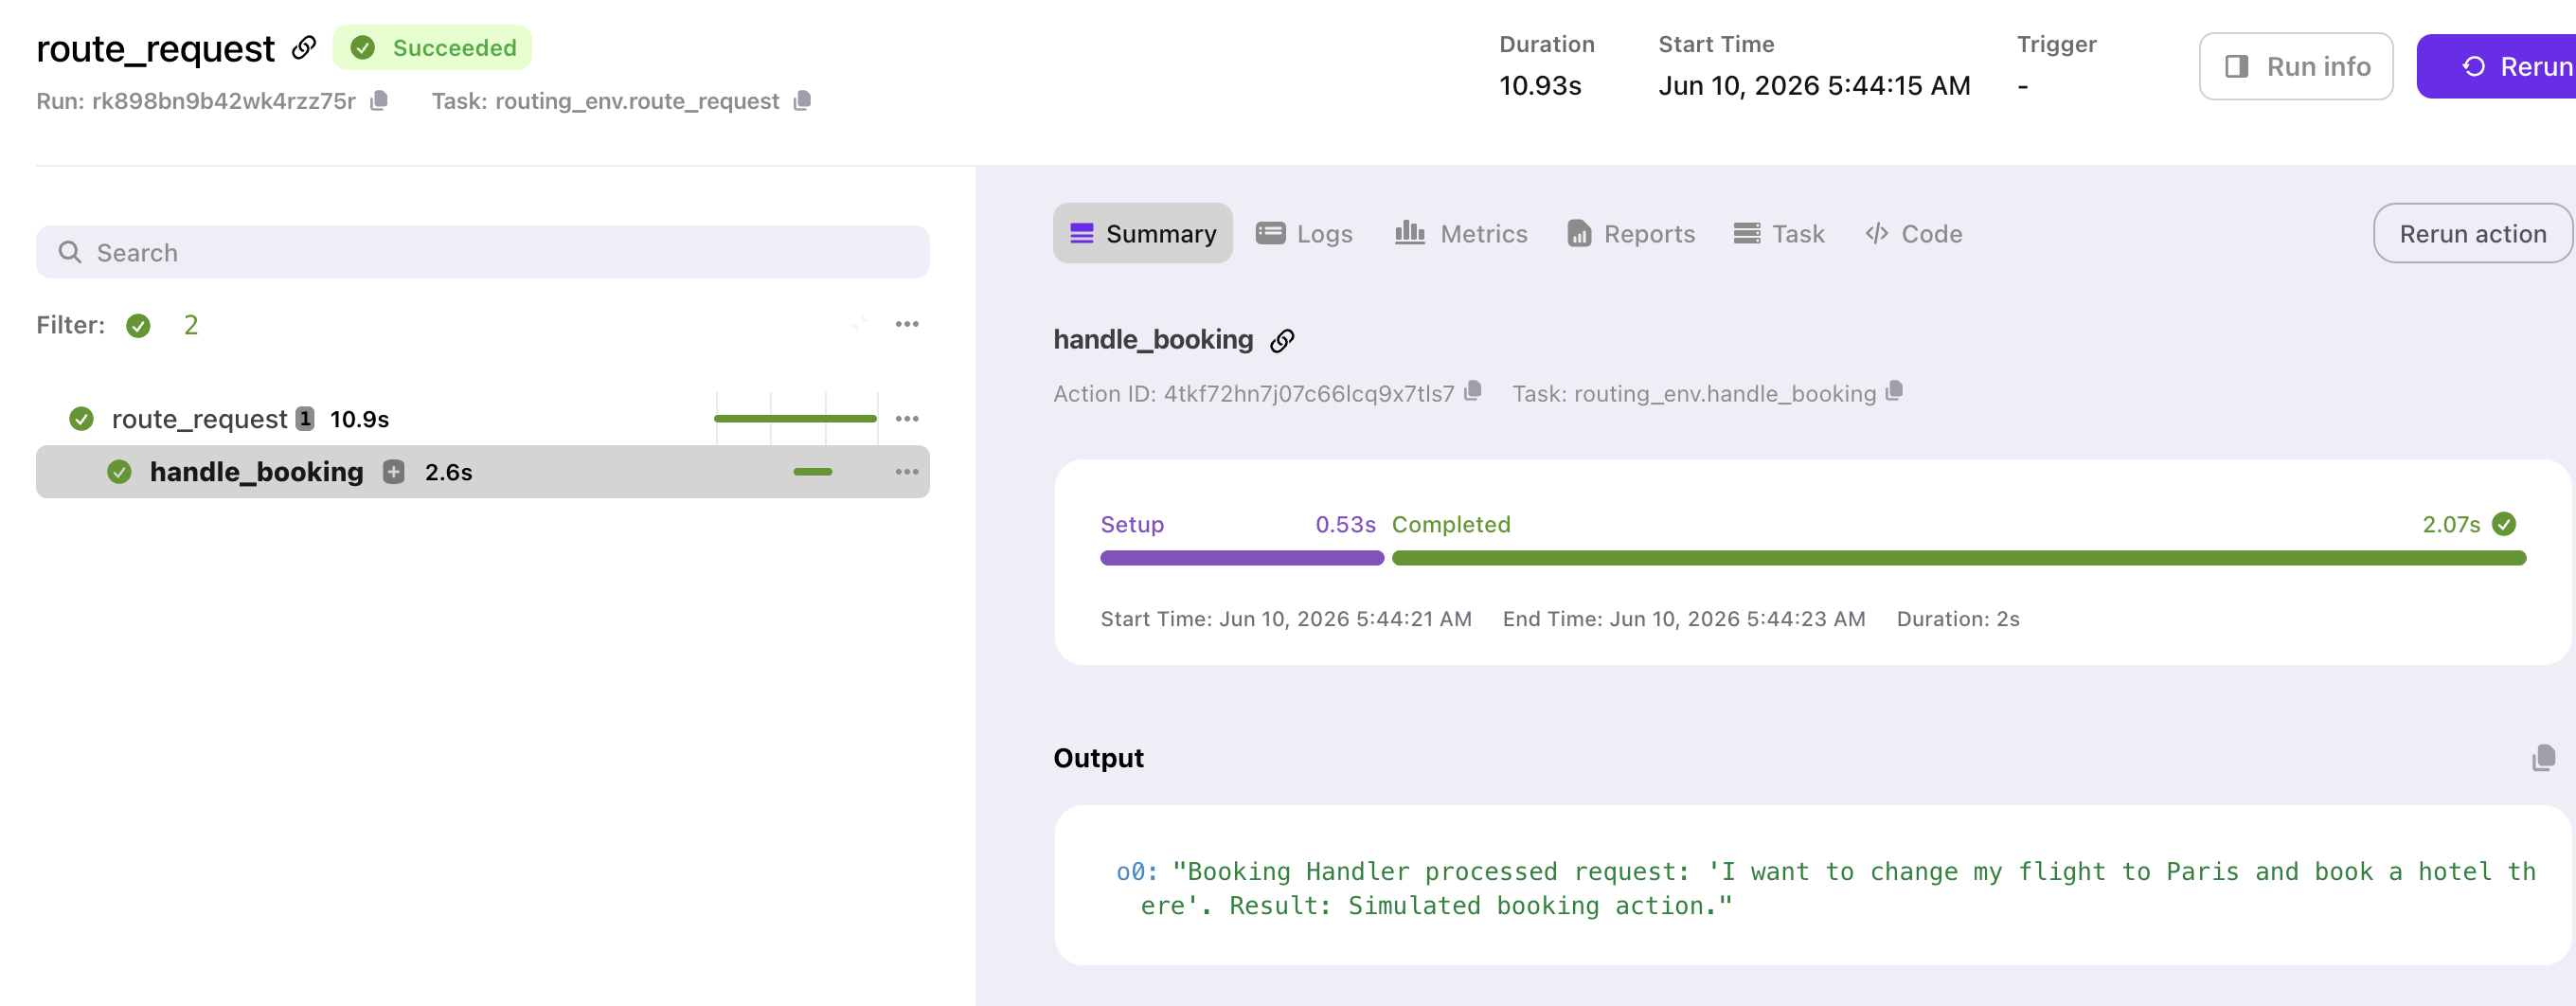



Let's see how it behaves with a different request:

In [12]:
run = flyte.run(route_request, request="What are the cancellation policies for my flight to Tokyo?")
run.wait()
print(run.outputs()[0])
print(run.url)

> Building 1 image...

> Building image flyte for environment routing_env

✓ Built image for environment routing_env: localhost:30000/flyte:c0e0f4726ed0c807007057a3d5d61d37

Output()

Based on your inquiry about cancellation policies for flights to Tokyo, I've retrieved the general policy information.

For specific details about **your particular flight** to Tokyo, including cancellation terms, refund eligibility, and deadlines, I'd recommend:

1. **Check your booking confirmation** – your ticket type and cancellation policy are listed there
2. **Review our cancellation policy** – policies vary based on:
   - Ticket type (Basic, Standard, Premium, etc.)
   - How far in advance you cancel
   - Whether the flight is domestic or international
   - The airline and route

Generally, most cancellations require notifying us before the flight departure time, and refunds depend on your ticket class.

**If you need to cancel or modify your specific Tokyo flight**, I can help you process that directly. Just let me know your booking reference or flight details, and I can assist with the cancellation or change.

Would you like me to help you cancel or modify your Tokyo flight?
h

This time it was sent to `handle_info`, demonstrating the router is following instructions:

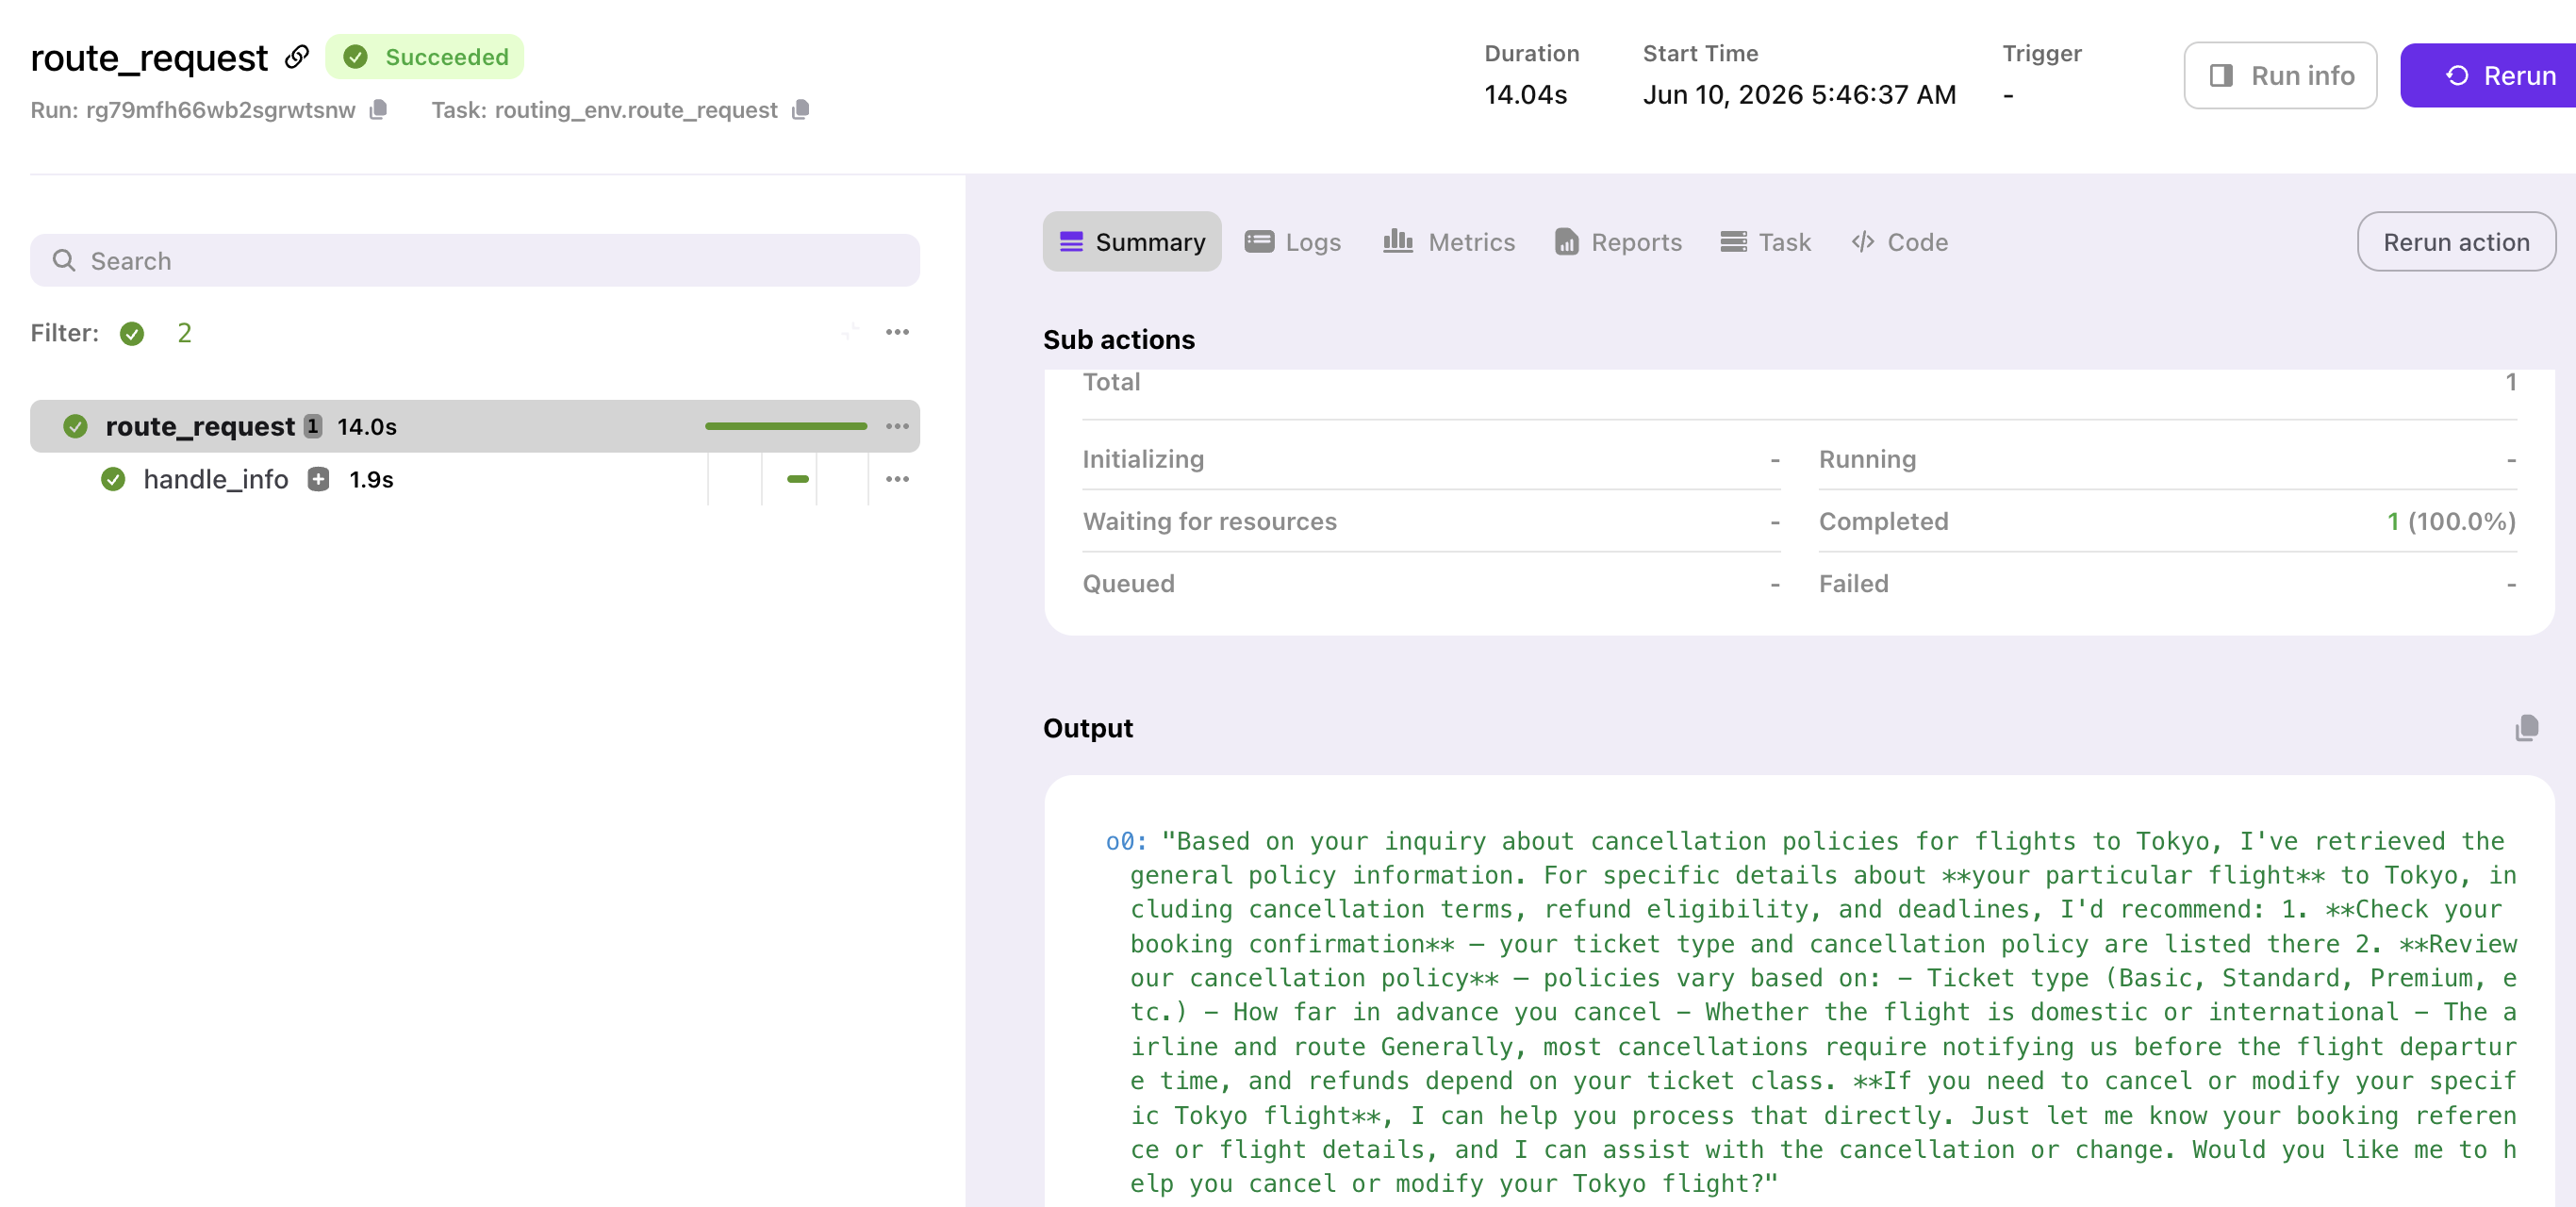

## Scaling the pattern

1. Make it batchable for multiple requests:

In [ ]:
@env.task
async def route_requests_batch(requests: list[str]) -> list[str]:
    """Route a batch of requests in parallel with bounded concurrency."""
    sem = asyncio.Semaphore(20)

    async def _one(req: str) -> str:
        async with sem:
            return await route_request(req)

    tasks = [_one(r) for r in requests]
    return list(await asyncio.gather(*tasks))